# 01 — Preparación del Dataset

Clasificación multi-label de patologías en radiografías de tórax.  
Datasets: **ChestXray8** (NIH) · **CheXpert** (Stanford) · **VinBigData** (Kaggle)

Este notebook cubre:
- **(a)** Clase `Dataset` de PyTorch y `DataLoader`
- **(b)** Particionado train / val / test
- **(c)** Preprocesamiento
- **(d)** Data augmentation
- **(e)** Verificación final del batch

## Setup

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Semilla global para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Directorio raíz del dataset (contiene ChestXray8/, chexpert/, VinBigData/)
DATASET_ROOT = os.path.abspath(os.path.join(".."))
DATA_DIR     = os.path.join(DATASET_ROOT, "data")

print(f"PyTorch:      {torch.__version__}")
print(f"torchvision:  {torchvision.__version__}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Data dir:     {DATA_DIR}")
assert os.path.exists(DATA_DIR), f"No se encuentra data/: {DATA_DIR}"

PyTorch:      2.12.0+cpu
torchvision:  0.27.0+cpu
Dataset root: e:\dataset
Data dir:     e:\dataset\data


## Labels canónicos

In [2]:
CANONICAL_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Pleural_Effusion", "Pneumonia", "Pneumothorax",
    "Infiltration", "Nodule_Mass", "Pleural_Thickening", "No_Finding",
]
NUM_CLASSES = len(CANONICAL_LABELS)
print(f"{NUM_CLASSES} clases:", CANONICAL_LABELS)

11 clases: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural_Effusion', 'Pneumonia', 'Pneumothorax', 'Infiltration', 'Nodule_Mass', 'Pleural_Thickening', 'No_Finding']


## (b) Particionado — Generación de CSVs

Loaders por dataset, mapeo a etiquetas canónicas y construcción de los cuatro splits:

| Archivo | Contenido |
|---|---|
| `data/train.csv` | CheXpert + ChestXray8 (85 % de train_val, split por `patient_id`) |
| `data/val.csv` | CheXpert + ChestXray8 (15 % de train_val, split por `patient_id`) |
| `data/test_interno.csv` | ChestXray8 test oficial (`test_list.txt`, ~25 k imágenes) |
| `data/test_externo.csv` | VinBigData completo (test de generalización externa, ~15 k imágenes) |

**Semántica de valores por fuente**

| Valor | Significado |
|---|---|
| `1.0` | Positivo — patología presente |
| `0.0` | Negativo — patología ausente |
| `-1.0` | Incierto — patología mencionada pero ambigua (solo CheXpert) |
| `NaN` | Ausencia estructural — la patología no forma parte del esquema de anotación del dataset |

| Dataset | Columnas con NaN estructural |
|---|---|
| CheXpert | `Infiltration`, `Nodule_Mass`, `Pleural_Thickening` |
| VinBigData | `Edema`, `Pneumonia` |

In [ ]:
from sklearn.model_selection import train_test_split

# ── ChestXray8 ────────────────────────────────────────────────────────────────
CX8_TO_CANONICAL = {
    "Atelectasis":        "Atelectasis",
    "Cardiomegaly":       "Cardiomegaly",
    "Consolidation":      "Consolidation",
    "Edema":              "Edema",
    "Effusion":           "Pleural_Effusion",
    "Infiltration":       "Infiltration",
    "Mass":               "Nodule_Mass",
    "Nodule":             "Nodule_Mass",
    "Pleural_Thickening": "Pleural_Thickening",
    "Pneumonia":          "Pneumonia",
    "Pneumothorax":       "Pneumothorax",
    "No Finding":         "No_Finding",
}

def load_chestxray8(root):
    meta = pd.read_csv(os.path.join(root, "ChestXray8", "Data_Entry_2017.csv"))

    # Build filename → relative path mapping across all images_XXX subfolders
    path_map = {}
    for folder in sorted(os.listdir(os.path.join(root, "ChestXray8"))):
        if folder.startswith("images_"):
            img_dir = os.path.join(root, "ChestXray8", folder, "images")
            if os.path.isdir(img_dir):
                for fname in os.listdir(img_dir):
                    path_map[fname] = f"ChestXray8/{folder}/images/{fname}"

    for canonical in CANONICAL_LABELS:
        meta[canonical] = 0.0
    for src_label, canonical in CX8_TO_CANONICAL.items():
        mask = meta["Finding Labels"].str.contains(src_label, regex=False)
        meta.loc[mask, canonical] = 1.0

    meta["image_id"]         = meta["Image Index"]
    meta["source"]           = "chestxray8"
    meta["image_path"]       = meta["Image Index"].map(path_map)
    meta["patient_id"]       = meta["Patient ID"].astype(str)
    meta["uncertainty_mask"] = False

    with open(os.path.join(root, "ChestXray8", "train_val_list.txt")) as f:
        train_val_ids = set(f.read().split())
    with open(os.path.join(root, "ChestXray8", "test_list.txt")) as f:
        test_ids = set(f.read().split())

    cols = ["image_id", "source", "image_path", "patient_id", "uncertainty_mask"] + CANONICAL_LABELS
    df_trainval = meta[meta["image_id"].isin(train_val_ids)][cols].reset_index(drop=True)
    df_test     = meta[meta["image_id"].isin(test_ids)][cols].reset_index(drop=True)
    return df_trainval, df_test


# ── CheXpert ──────────────────────────────────────────────────────────────────
CHEXPERT_TO_CANONICAL = {
    "No Finding":      "No_Finding",
    "Cardiomegaly":    "Cardiomegaly",
    "Edema":           "Edema",
    "Consolidation":   "Consolidation",
    "Pneumonia":       "Pneumonia",
    "Atelectasis":     "Atelectasis",
    "Pneumothorax":    "Pneumothorax",
    "Pleural Effusion": "Pleural_Effusion",
}
# Absent in CheXpert → NaN: Infiltration, Nodule_Mass, Pleural_Thickening

def _chexpert_flat_path(path_str):
    # "CheXpert-v1.0-small/train/patientXXXX/studyY/viewZ.jpg"
    # → "chexpert/train/patientXXXX_studyY_viewZ.jpg"
    parts = path_str.replace("\\", "/").split("/")
    patient, study, fname = parts[-3], parts[-2], parts[-1]
    split_dir = parts[-4]  # "train" or "valid"
    return f"chexpert/{split_dir}/{patient}_{study}_{fname}"

def load_chexpert(root):
    df = pd.read_csv(os.path.join(root, "chexpert", "train.csv"))

    src_cols = list(CHEXPERT_TO_CANONICAL.keys())

    # uncertainty_mask: True for rows that had at least one -1 in any mapped label
    uncertainty_mask = (df[src_cols] == -1).any(axis=1)

    # -1 (incierto) se preserva tal cual; NaN queda solo para ausencia estructural
    labels_df = pd.DataFrame(float("nan"), index=df.index, columns=CANONICAL_LABELS)
    for src_col, canonical in CHEXPERT_TO_CANONICAL.items():
        labels_df[canonical] = df[src_col].values

    df["patient_id"]       = df["Path"].str.extract(r"(patient\d+)")
    df["image_id"]         = df["Path"].apply(lambda p: _chexpert_flat_path(p).split("/")[-1])
    df["image_path"]       = df["Path"].apply(_chexpert_flat_path)
    df["source"]           = "chexpert"
    df["uncertainty_mask"] = uncertainty_mask.values

    meta = df[["image_id", "source", "image_path", "patient_id", "uncertainty_mask"]].reset_index(drop=True)
    return pd.concat([meta, labels_df.reset_index(drop=True)], axis=1)


# ── VinBigData ────────────────────────────────────────────────────────────────
VIN_TO_CANONICAL = {
    "No finding":         "No_Finding",
    "Atelectasis":        "Atelectasis",
    "Cardiomegaly":       "Cardiomegaly",
    "Consolidation":      "Consolidation",
    "Pleural effusion":   "Pleural_Effusion",
    "Pleural thickening": "Pleural_Thickening",
    "Pneumothorax":       "Pneumothorax",
    "Infiltration":       "Infiltration",
    "Nodule/Mass":        "Nodule_Mass",
}
# Absent in VinBigData → NaN: Edema, Pneumonia
VIN_ABSENT = {"Edema", "Pneumonia"}

def load_vinbigdata(root):
    df = pd.read_csv(os.path.join(root, "VinBigData", "train.csv"))

    df["canonical"] = df["class_name"].map(VIN_TO_CANONICAL)
    df_mapped = df.dropna(subset=["canonical"])

    # Count distinct radiologists voting for each (image, canonical label)
    votes = (
        df_mapped.groupby(["image_id", "canonical"])["rad_id"]
        .nunique()
        .reset_index()
        .rename(columns={"rad_id": "n_votes"})
    )
    n_rads_per_img = df.groupby("image_id")["rad_id"].nunique()
    votes["threshold"] = votes["image_id"].map(n_rads_per_img) * 0.5
    votes["positive"]  = (votes["n_votes"] >= votes["threshold"]).astype(float)

    all_images = df["image_id"].unique()

    label_matrix = (
        votes.pivot(index="image_id", columns="canonical", values="positive")
        .reindex(index=all_images, columns=CANONICAL_LABELS)
        .fillna(0.0)
        .reset_index()
    )
    label_matrix.columns.name = None
    for col in VIN_ABSENT:
        label_matrix[col] = float("nan")

    label_matrix["source"]          = "vinbigdata"
    label_matrix["image_path"]      = "VinBigData/train/" + label_matrix["image_id"] + ".jpg"
    label_matrix["patient_id"]      = label_matrix["image_id"]
    label_matrix["uncertainty_mask"] = False

    return label_matrix[["image_id", "source", "image_path", "patient_id", "uncertainty_mask"] + CANONICAL_LABELS]


print("Funciones de carga definidas: load_chestxray8 · load_chexpert · load_vinbigdata")

In [4]:
os.makedirs(DATA_DIR, exist_ok=True)

# ── 1. Cargar datasets ──────────────────────────────────────────────────────
print("Cargando ChestXray8...")
df_cx8_trainval, df_cx8_test = load_chestxray8(DATASET_ROOT)
print(f"  train_val: {len(df_cx8_trainval):,}  |  test: {len(df_cx8_test):,}")

print("Cargando CheXpert...")
df_chex = load_chexpert(DATASET_ROOT)
print(f"  total: {len(df_chex):,}  |  filas con uncertainty_mask: {df_chex['uncertainty_mask'].sum():,}")

print("Cargando VinBigData...")
df_vin = load_vinbigdata(DATASET_ROOT)
print(f"  total: {len(df_vin):,}")

# ── 2. Split ChestXray8 train_val → 85 % train / 15 % val (por patient_id) ──
cx8_patients = df_cx8_trainval["patient_id"].unique()
cx8_train_pats, cx8_val_pats = train_test_split(
    cx8_patients, test_size=0.15, random_state=SEED
)
df_train_cx8 = df_cx8_trainval[df_cx8_trainval["patient_id"].isin(cx8_train_pats)]
df_val_cx8   = df_cx8_trainval[df_cx8_trainval["patient_id"].isin(cx8_val_pats)]
print(f"\nChestXray8  train: {len(df_train_cx8):,} "
      f"({len(df_train_cx8)/len(df_cx8_trainval)*100:.1f} %)  "
      f"val: {len(df_val_cx8):,} "
      f"({len(df_val_cx8)/len(df_cx8_trainval)*100:.1f} %)")

# ── 3. Split CheXpert → 85 % train / 15 % val (por patient_id) ─────────────
chex_patients = df_chex["patient_id"].unique()
chex_train_pats, chex_val_pats = train_test_split(
    chex_patients, test_size=0.15, random_state=SEED
)
df_train_chex = df_chex[df_chex["patient_id"].isin(chex_train_pats)]
df_val_chex   = df_chex[df_chex["patient_id"].isin(chex_val_pats)]
print(f"CheXpert    train: {len(df_train_chex):,} "
      f"({len(df_train_chex)/len(df_chex)*100:.1f} %)  "
      f"val: {len(df_val_chex):,} "
      f"({len(df_val_chex)/len(df_chex)*100:.1f} %)")

# ── 4. Construir splits finales ─────────────────────────────────────────────
# VinBigData → 100 % test externo (no entra en train ni val)
df_train    = pd.concat([df_train_cx8, df_train_chex], ignore_index=True)
df_val      = pd.concat([df_val_cx8,   df_val_chex],   ignore_index=True)
df_test_int = df_cx8_test.copy()
df_test_ext = df_vin.copy()

# ── 5. Guardar CSVs ─────────────────────────────────────────────────────────
df_train.to_csv(   os.path.join(DATA_DIR, "train.csv"),         index=False)
df_val.to_csv(     os.path.join(DATA_DIR, "val.csv"),           index=False)
df_test_int.to_csv(os.path.join(DATA_DIR, "test_interno.csv"),  index=False)
df_test_ext.to_csv(os.path.join(DATA_DIR, "test_externo.csv"),  index=False)

# ── 6. Verificación de distribución por source ──────────────────────────────
all_splits = {
    "train":        df_train,
    "val":          df_val,
    "test_interno": df_test_int,
    "test_externo": df_test_ext,
}
print("\n" + "=" * 72)
print(f"{'Split':<14} {'Total':>8}  {'ChestXray8':>12}  {'CheXpert':>10}  {'VinBig':>8}")
print("=" * 72)
for name, df in all_splits.items():
    vc = df["source"].value_counts()
    print(f"{name:<14} {len(df):>8,}  "
          f"{vc.get('chestxray8', 0):>12,}  "
          f"{vc.get('chexpert',   0):>10,}  "
          f"{vc.get('vinbigdata', 0):>8,}")

print(f"\nuncertainty_mask en train: {df_train['uncertainty_mask'].sum():,} filas")
print(f"uncertainty_mask en val:   {df_val['uncertainty_mask'].sum():,} filas")

Cargando ChestXray8...
  train_val: 86,524  |  test: 25,596
Cargando CheXpert...
  total: 223,414  |  filas con uncertainty_mask: 73,497
Cargando VinBigData...
  total: 15,000

ChestXray8  train: 73,916 (85.4 %)  val: 12,608 (14.6 %)
CheXpert    train: 190,359 (85.2 %)  val: 33,055 (14.8 %)

Split             Total    ChestXray8    CheXpert    VinBig
train           264,275        73,916     190,359         0
val              45,663        12,608      33,055         0
test_interno     25,596        25,596           0         0
test_externo     15,000             0           0    15,000

uncertainty_mask en train: 62,769 filas
uncertainty_mask en val:   10,728 filas


## (a) Clase Dataset

`ChestXRayDataset` hereda de `torch.utils.data.Dataset` e implementa los tres métodos requeridos:
- `__init__`: lee el CSV y guarda la ruta raíz
- `__len__`: retorna la cantidad de muestras
- `__getitem__`: carga la imagen, convierte a RGB (los chest X-rays son grayscale; DenseNet121 espera 3 canales), y construye el tensor de labels

Los labels `NaN` se rellenan con `0.0` (tratados como negativos). Esto simplifica el entrenamiento; una alternativa más correcta sería usar una loss enmascarada que ignore las posiciones `NaN`.

In [5]:
class ChestXRayDataset(Dataset):
    def __init__(self, csv_path, root_dir, labels=CANONICAL_LABELS, transform=None, nan_fill=0.0):
        self.df        = pd.read_csv(csv_path)
        self.root_dir  = root_dir
        self.labels    = labels
        self.transform = transform
        self.nan_fill  = nan_fill

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        img      = Image.open(img_path).convert("RGB")
        label_vals = row[self.labels].fillna(self.nan_fill).values.astype("float32")
        labels   = torch.tensor(label_vals)
        if self.transform:
            img = self.transform(img)
        return img, labels

print("Clase ChestXRayDataset definida.")

Clase ChestXRayDataset definida.


## (c) Preprocesamiento

Se usa un modelo preentrenado en ImageNet (DenseNet121) que espera:
- Imágenes de **224×224** píxeles
- 3 canales RGB
- Normalización con `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`

Para **val** y **test** no hay augmentation — solo resize + normalización.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transform val/test definido.")

Transform val/test definido.


## (d) Data Augmentation (solo train)

Las augmentations se eligen considerando las características de las radiografías de tórax:

| Transformación | Por qué tiene sentido |
|---|---|
| `RandomCrop(224)` desde resize 256 | Pequeñas variaciones de encuadre, igual al protocolo ResNet original |
| `RandomHorizontalFlip(p=0.5)` | El corazón es levemente asimétrico pero la flip es aceptada en la literatura clínica |
| `RandomRotation(±10°)` | Simula variaciones en el posicionamiento del paciente |
| `ColorJitter(brightness, contrast)` | Simula variaciones en la configuración del equipo de rayos X |
| `FourierAmplitudeMixup(β=0.1, p=0.5)` | Intercambia las componentes de baja frecuencia del espectro de Fourier con una imagen aleatoria del pool de train — simula variaciones de equipamiento/exposición sin alterar la estructura anatómica (fase). Efectivo en imagen médica multicentro. |

**NO** se aplica: flip vertical (anatomía incorrecta), zoom agresivo (recorta pulmones), ni distorsiones geométricas fuertes.

In [7]:
class FourierAmplitudeMixup:
    """
    Swaps low-frequency Fourier amplitudes between the target image and a
    randomly drawn image from the training pool.  Phase (structure/pathology)
    is preserved; amplitude (brightness/contrast style) is borrowed.

    β  — fraction of image size used as the low-freq window radius.
    p  — probability of applying the augmentation per image.

    Ref: Yang & Soatto (2020), "FDA: Fourier Domain Adaptation for Semantic
    Segmentation", CVPR 2020.
    """
    def __init__(self, pool_paths, root_dir, beta=0.1, p=0.5):
        self.pool_paths = list(pool_paths)
        self.root_dir   = root_dir
        self.beta       = beta
        self.p          = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        src_path = random.choice(self.pool_paths)
        src_img  = Image.open(os.path.join(self.root_dir, src_path)).convert("RGB")
        src_img  = src_img.resize(img.size, Image.BILINEAR)

        img_np = np.array(img).astype(np.float32)
        src_np = np.array(src_img).astype(np.float32)

        mixed = np.stack([
            self._mix_channel(img_np[:, :, c], src_np[:, :, c])
            for c in range(3)
        ], axis=2)
        return Image.fromarray(np.clip(mixed, 0, 255).astype(np.uint8))

    def _mix_channel(self, img_c, src_c):
        F_img = np.fft.fft2(img_c)
        F_src = np.fft.fft2(src_c)

        amp_img = np.fft.fftshift(np.abs(F_img))
        amp_src = np.fft.fftshift(np.abs(F_src))
        phase   = np.angle(F_img)

        h, w   = img_c.shape
        bh, bw = int(h * self.beta), int(w * self.beta)
        ch, cw = h // 2, w // 2

        amp_mix = amp_img.copy()
        amp_mix[ch - bh:ch + bh, cw - bw:cw + bw] = \
            amp_src[ch - bh:ch + bh, cw - bw:cw + bw]

        F_mix = np.fft.ifftshift(amp_mix) * np.exp(1j * phase)
        return np.real(np.fft.ifft2(F_mix))


# Pool de imágenes para FA-Mixup (todas las imágenes de train)
_train_pool = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))["image_path"].tolist()

fourier_mixup = FourierAmplitudeMixup(
    pool_paths = _train_pool,
    root_dir   = DATASET_ROOT,
    beta       = 0.1,
    p          = 0.5,
)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    fourier_mixup,
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f"FourierAmplitudeMixup: β={fourier_mixup.beta}, p={fourier_mixup.p}, "
      f"pool={len(_train_pool):,} imágenes")
print("Transform train con augmentation definido.")

FourierAmplitudeMixup: β=0.1, p=0.5, pool=264,275 imágenes
Transform train con augmentation definido.


C:\Users\jqncl\AppData\Local\Temp\ipykernel_4700\2631135123.py:56: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  _train_pool = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))["image_path"].tolist()


### Visualización del efecto de las augmentations

Se toman 4 imágenes del set de train y se muestran 4 versiones aumentadas de cada una. Las augmentations **NO incluyen la normalización** para que las imágenes sean visualmente interpretables.

C:\Users\jqncl\AppData\Local\Temp\ipykernel_4700\780838177.py:11: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  train_csv = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))


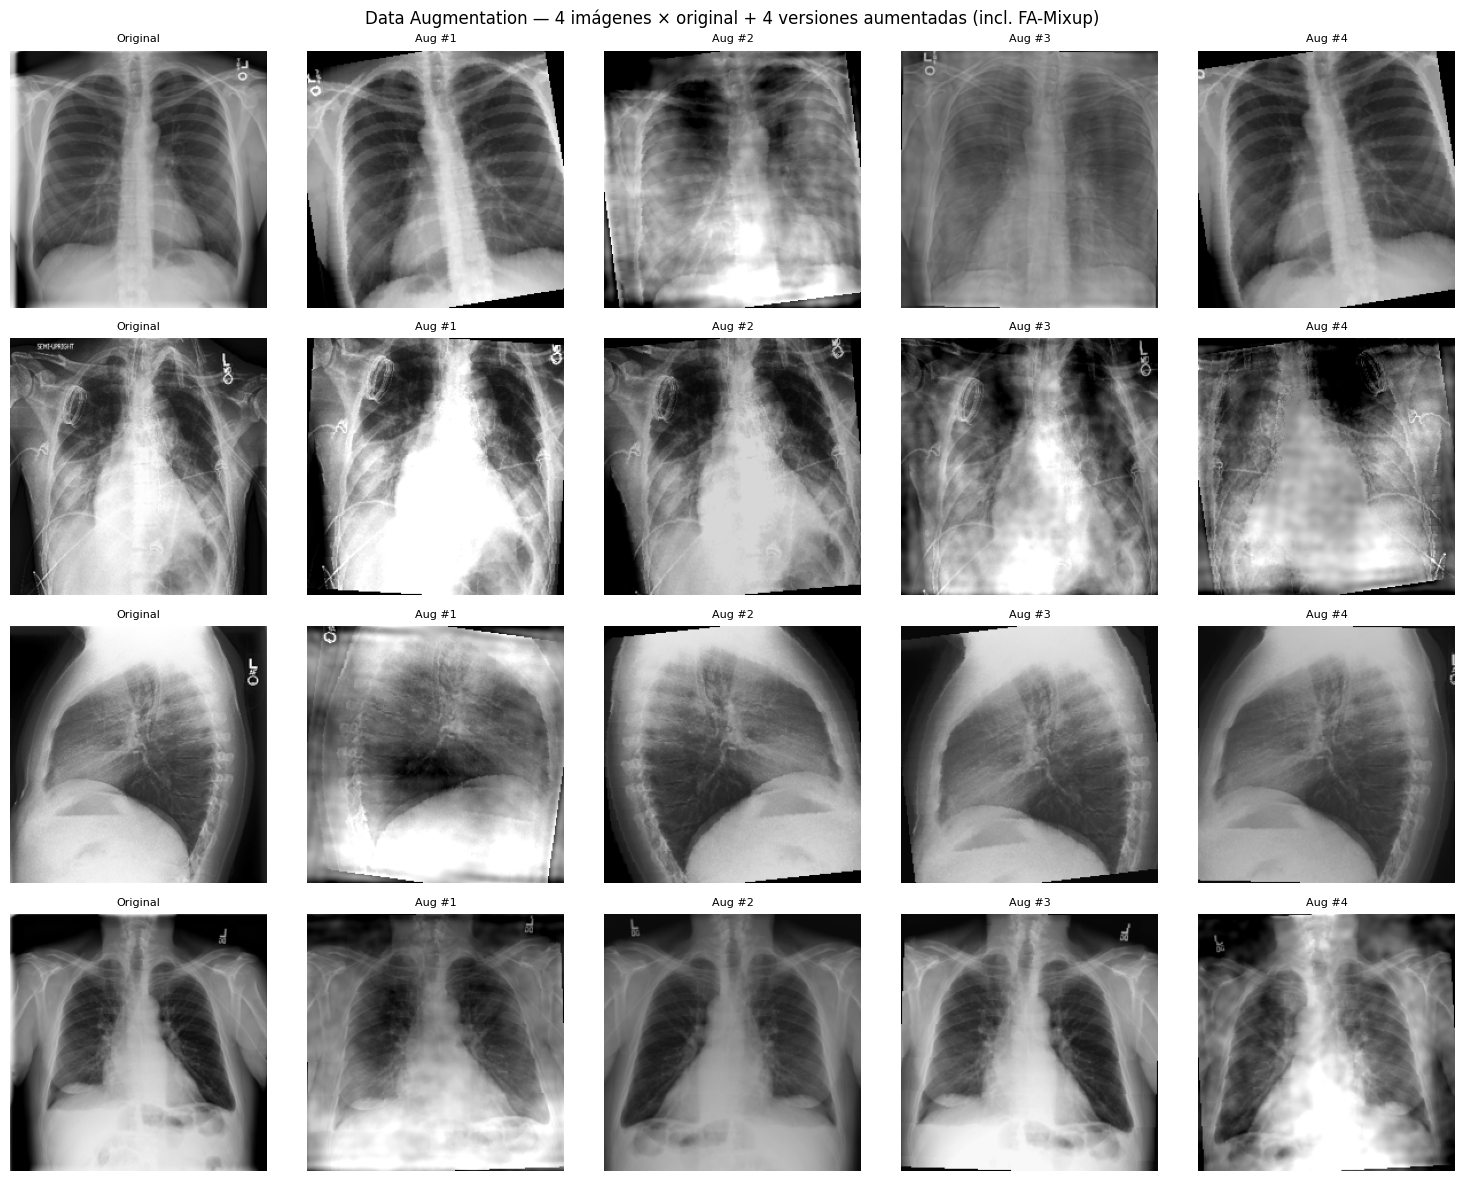

In [8]:
# Transform solo para visualización (sin normalización)
aug_vis_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    fourier_mixup,
])

train_csv = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
sample_rows = train_csv.sample(4, random_state=SEED)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle("Data Augmentation — 4 imágenes × original + 4 versiones aumentadas (incl. FA-Mixup)", fontsize=12)

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    img_path = os.path.join(DATASET_ROOT, row["image_path"])
    original = Image.open(img_path).convert("RGB").resize((224, 224))

    axes[row_idx, 0].imshow(original, cmap="gray")
    axes[row_idx, 0].set_title("Original", fontsize=8)
    axes[row_idx, 0].axis("off")

    active = [l for l in CANONICAL_LABELS if row[l] == 1.0]
    label_str = ", ".join(active) if active else "No Finding"
    axes[row_idx, 0].set_xlabel(label_str, fontsize=6, wrap=True)

    for aug_idx in range(1, 5):
        augmented = aug_vis_transform(Image.open(img_path).convert("RGB"))
        axes[row_idx, aug_idx].imshow(augmented, cmap="gray")
        axes[row_idx, aug_idx].set_title(f"Aug #{aug_idx}", fontsize=8)
        axes[row_idx, aug_idx].axis("off")

plt.tight_layout()
plt.show()

## (a) DataLoaders

In [9]:
BATCH_SIZE  = 32
NUM_WORKERS = 0

train_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "train.csv"),
    root_dir  = DATASET_ROOT,
    transform = train_transform,
)
val_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "val.csv"),
    root_dir  = DATASET_ROOT,
    transform = val_test_transform,
)
test_int_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "test_interno.csv"),
    root_dir  = DATASET_ROOT,
    transform = val_test_transform,
)
test_ext_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "test_externo.csv"),
    root_dir  = DATASET_ROOT,
    transform = val_test_transform,
)

train_loader    = DataLoader(train_ds,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_int_loader = DataLoader(test_int_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_ext_loader = DataLoader(test_ext_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"train_ds:    {len(train_ds):,} imágenes")
print(f"val_ds:      {len(val_ds):,} imágenes")
print(f"test_int_ds: {len(test_int_ds):,} imágenes")
print(f"test_ext_ds: {len(test_ext_ds):,} imágenes")
print(f"\nbatch_size:  {BATCH_SIZE}")
print(f"num_workers: {NUM_WORKERS}")
print(f"shuffle train: True   |   shuffle val/test: False")

train_ds:    264,275 imágenes
val_ds:      45,663 imágenes
test_int_ds: 25,596 imágenes
test_ext_ds: 15,000 imágenes

batch_size:  32
num_workers: 0
shuffle train: True   |   shuffle val/test: False


C:\Users\jqncl\AppData\Local\Temp\ipykernel_4700\2327315289.py:3: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df        = pd.read_csv(csv_path)


## (b) Particionado

### Criterio de partición

| Dataset | Estrategia | Fuente |
|---|---|---|
| **ChestXray8** | Split oficial | `train_val_list.txt` → train/val, `test_list.txt` → test |
| **CheXpert** | Split oficial | `train.csv` → train/val, `valid.csv` → test |
| **VinBigData** | Aleatorio 80/20 | split por `image_id`, `random_state=42` |
| **Validación** | 15% de train | split por `image_id`, `random_state=42` |

El split se hace a nivel de `image_id` (no por fila) para evitar que distintas vistas del mismo estudio queden simultáneamente en train y val.

In [10]:
splits = {
    "train":        pd.read_csv(os.path.join(DATA_DIR, "train.csv")),
    "val":          pd.read_csv(os.path.join(DATA_DIR, "val.csv")),
    "test_interno": pd.read_csv(os.path.join(DATA_DIR, "test_interno.csv")),
    "test_externo": pd.read_csv(os.path.join(DATA_DIR, "test_externo.csv")),
}

print("=" * 72)
print(f"{'Split':<14} {'Total':>8}  {'ChestXray8':>12}  {'CheXpert':>10}  {'VinBig':>8}")
print("=" * 72)
for name, df in splits.items():
    vc = df["source"].value_counts()
    print(f"{name:<14} {len(df):>8,}  "
          f"{vc.get('chestxray8', 0):>12,}  "
          f"{vc.get('chexpert',   0):>10,}  "
          f"{vc.get('vinbigdata', 0):>8,}")

print("\nPositivos por label en train (valor == 1.0):")
total_train = len(splits["train"])
pos_train   = (splits["train"][CANONICAL_LABELS] == 1.0).sum()
dist_table  = pd.DataFrame({
    "train_pos":  pos_train,
    "% train":    (pos_train / total_train * 100).round(1),
    "val_pos":    (splits["val"][CANONICAL_LABELS]          == 1.0).sum(),
    "test_int":   (splits["test_interno"][CANONICAL_LABELS] == 1.0).sum(),
    "test_ext":   (splits["test_externo"][CANONICAL_LABELS] == 1.0).sum(),
})
print(dist_table.to_string())

C:\Users\jqncl\AppData\Local\Temp\ipykernel_4700\1018576753.py:2: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  "train":        pd.read_csv(os.path.join(DATA_DIR, "train.csv")),


Split             Total    ChestXray8    CheXpert    VinBig
train           264,275        73,916     190,359         0
val              45,663        12,608      33,055         0
test_interno     25,596        25,596           0         0
test_externo     15,000             0           0    15,000

Positivos por label en train (valor == 1.0):
                    train_pos  % train  val_pos  test_int  test_ext
Atelectasis             35462     13.4     6194      3279        62
Cardiomegaly            24382      9.2     4325      1069      1817
Consolidation           15160      5.7     2475      1815       121
Edema                   45749     17.3     7875       925         0
Pleural_Effusion        81003     30.7    13843      4658       634
Pneumonia                5872      2.2     1043       555         0
Pneumothorax            18735      7.1     3350      2665        58
Infiltration            11853      4.5     1929      6112       245
Nodule_Mass              6987      2.6    

## (e) Verificación final del batch

In [11]:
imgs, labels = next(iter(train_loader))

print(f"Tensor imágenes : {imgs.shape}   (batch_size, canales, alto, ancho)")
print(f"Tensor labels   : {labels.shape}  (batch_size, num_clases)")
print(f"Rango de valores normalizados: [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"dtype imágenes  : {imgs.dtype}")
print(f"dtype labels    : {labels.dtype}")
print(f"Valores únicos en labels: {labels.unique().tolist()}")

e:\dataset\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tensor imágenes : torch.Size([32, 3, 224, 224])   (batch_size, canales, alto, ancho)
Tensor labels   : torch.Size([32, 11])  (batch_size, num_clases)
Rango de valores normalizados: [-2.118, 2.640]
dtype imágenes  : torch.float32
dtype labels    : torch.float32
Valores únicos en labels: [0.0, 1.0]


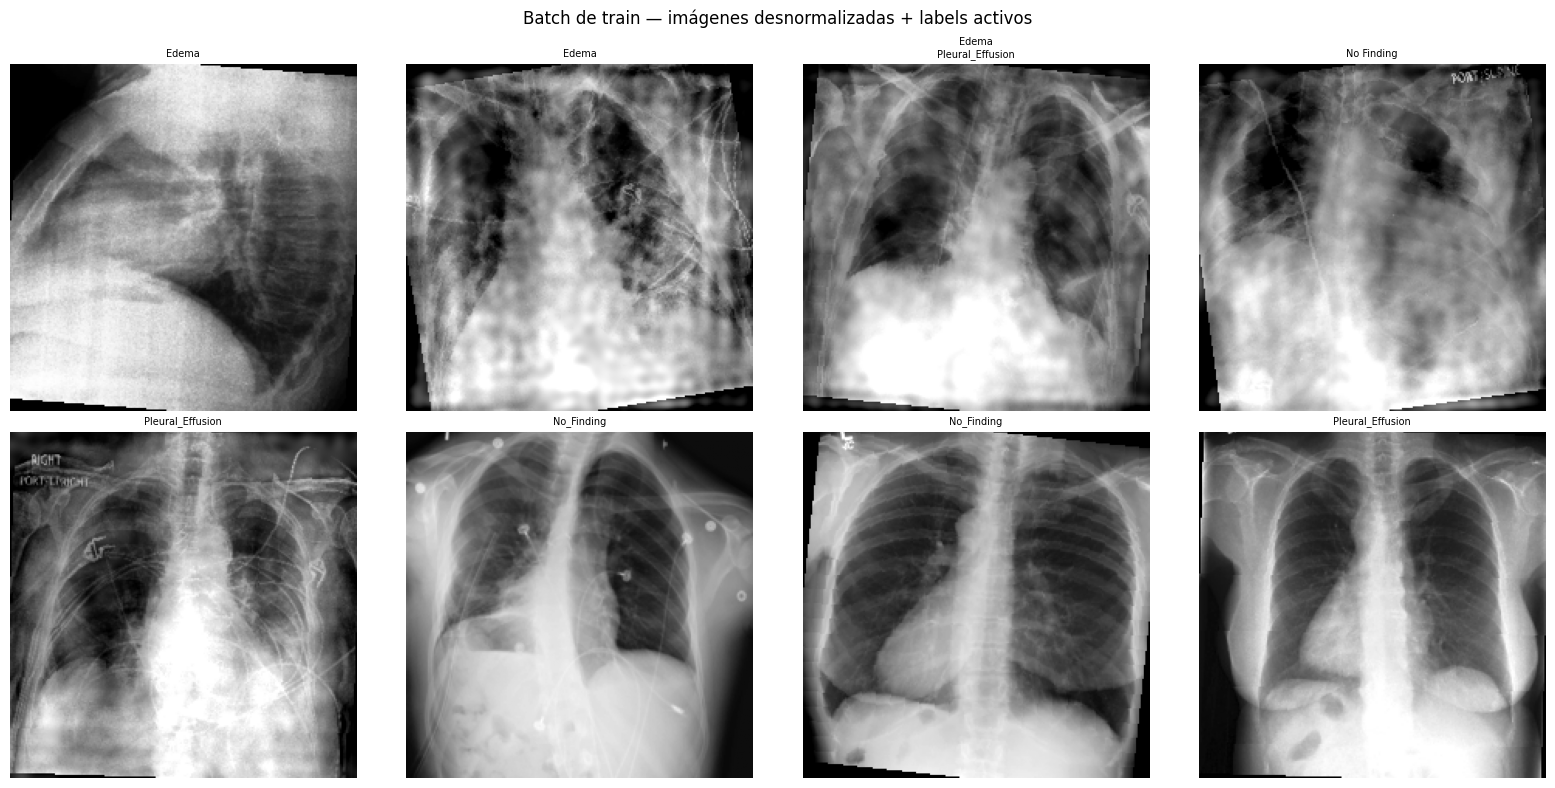

Verificación completa: pares imagen-etiqueta correctos.


In [12]:
# Desnormalizar y visualizar 8 imágenes del batch con sus labels
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

imgs_denorm = (imgs * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Batch de train — imágenes desnormalizadas + labels activos", fontsize=12)

for i, ax in enumerate(axes.flat):
    # Convertir tensor a numpy y transponer (C, H, W) -> (H, W, C)
    img_np = imgs_denorm[i].permute(1, 2, 0).numpy()
    # Radiografías son en escala de grises; mostrar canal promedio
    ax.imshow(img_np.mean(axis=2), cmap="gray")

    active = [CANONICAL_LABELS[j] for j, v in enumerate(labels[i]) if v == 1.0]
    label_str = "\n".join(active) if active else "No Finding"
    ax.set_title(label_str, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("Verificación completa: pares imagen-etiqueta correctos.")

In [13]:
# Verificación de leakage: ningún patient_id debe aparecer en train Y val
train_csv = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_csv   = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))

for src in ["chexpert", "chestxray8"]:
    train_pids = set(train_csv[train_csv["source"] == src]["patient_id"].dropna())
    val_pids   = set(val_csv[val_csv["source"]   == src]["patient_id"].dropna())
    leak       = train_pids & val_pids
    print(f"{src:<12}  train patients: {len(train_pids):,}  "
          f"val patients: {len(val_pids):,}  "
          f"leakage: {len(leak)}")
    assert len(leak) == 0, f"LEAKAGE DETECTADO en {src}: {len(leak)} pacientes en train y val"

print("\n✓ Sin leakage de patient_id entre train y val.")

chexpert      train patients: 54,859  val patients: 9,681  leakage: 0
chestxray8    train patients: 23,806  val patients: 4,202  leakage: 0

✓ Sin leakage de patient_id entre train y val.


C:\Users\jqncl\AppData\Local\Temp\ipykernel_4700\339597650.py:2: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  train_csv = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
